In [1]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\Parameter\01. Air\swim_ice_consistency_1-5m.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Ice_Consistency": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("ice_consistency_1-5m_bener.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude  Ice_Consistency
0        0.5       0.5              0.0
1        1.5       0.5              0.0
2        2.5       0.5              0.0
3        3.5       0.5              0.0
4        4.5       0.5              0.0


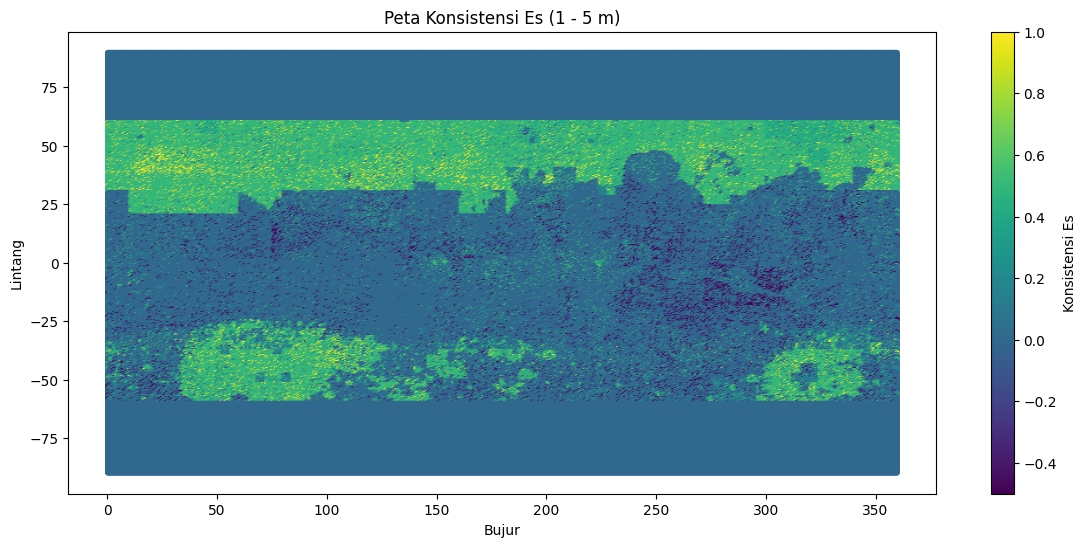

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\Ice\1-5\ice_consistency_1-5m_bener.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 720
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 360)

# Plot data
plt.figure(figsize=(14, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Konsistensi Es")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Konsistensi Es (1 - 5 m)")


plt.show()

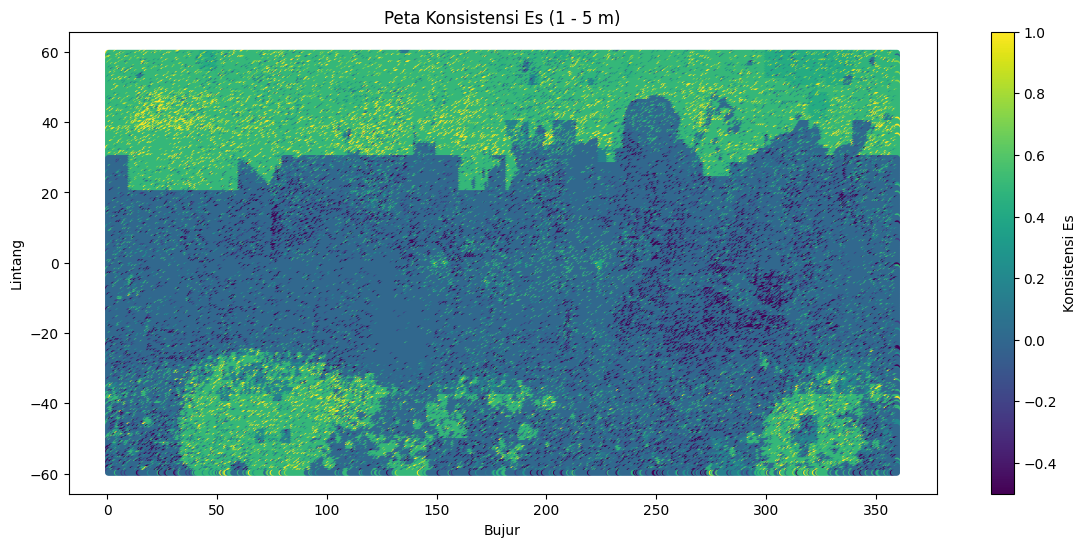

In [3]:
df_nonkutub = df_bersih[(df_bersih["Latitude"] < 60) & (df_bersih["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Konsistensi Es")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Konsistensi Es (1 - 5 m)")
# balik sumbu y
plt.show()

In [4]:
# hitung frekuensi
counts = df_nonkutub["Ice_Consistency"].value_counts().sort_index()

print(counts)


Ice_Consistency
-0.500     5835
-0.450       50
-0.400       80
-0.350      118
-0.300       16
-0.250     4218
-0.200       50
-0.150       68
-0.125        2
-0.100      128
-0.075       36
-0.050       14
-0.025       59
 0.000    93230
 0.050      977
 0.100      999
 0.125        2
 0.150     2169
 0.175       76
 0.200      271
 0.225       73
 0.250     6367
 0.300       64
 0.350       79
 0.375       88
 0.400      180
 0.425     1679
 0.450       21
 0.475     1420
 0.500    47585
 0.550       96
 0.600       72
 0.625        6
 0.650      134
 0.675      101
 0.700       12
 0.725       64
 0.750     3059
 0.875        7
 0.925       66
 0.975       81
 1.000     3148
Name: count, dtype: int64


In [4]:
df_after0 = df_bersih[(df_bersih["Ice_Consistency"] > 0)]
print(df_after0.head())

       Longitude  Latitude  Ice_Consistency
43200       0.25     59.75              1.0
43201       0.75     59.75              0.5
43202       1.25     59.75              0.5
43203       1.75     59.75              0.5
43204       2.25     59.75              0.5


In [5]:
counts_after0 = df_after0["Ice_Consistency"].value_counts().sort_index()

print(counts_after0)

Ice_Consistency
0.050      977
0.100      999
0.125        2
0.150     2169
0.175       76
0.200      271
0.225       73
0.250     6367
0.300       64
0.350       79
0.375       88
0.400      180
0.425     1679
0.450       21
0.475     1420
0.500    47585
0.550       96
0.600       72
0.625        6
0.650      134
0.675      101
0.700       12
0.725       64
0.750     3059
0.875        7
0.925       66
0.975       81
1.000     3148
Name: count, dtype: int64


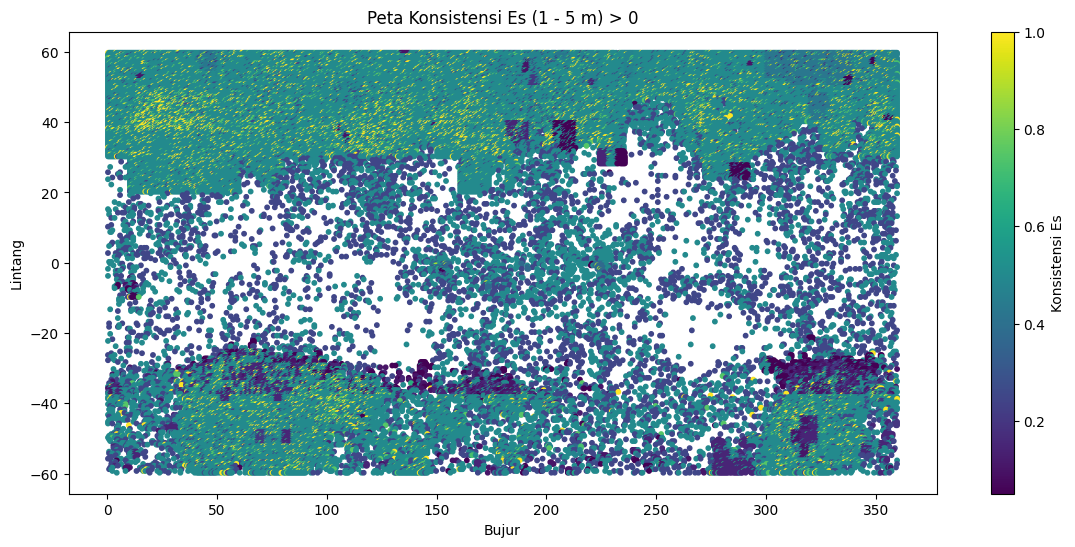

In [6]:
# Plot data
plt.figure(figsize=(14, 6))
plt.scatter(df_after0["Longitude"], df_after0["Latitude"], c=df_after0["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Konsistensi Es")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Konsistensi Es (1 - 5 m) > 0")


plt.show()